In [ ]:
import copy
import warnings
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

warnings.filterwarnings("ignore")

In [ ]:
# --- КОНСТАНТЫ И ПУТИ ---
PATH_TRAIN_AUG = 'data/train_augmented_1000_full.csv'
PATH_VAL_CLEAN = 'data/val_clean_50_full.csv'
PATH_TEST = 'data/test.csv'

DEVICE = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

TARGET_COLS_INTERNAL = ["target_visc", "target_oxid"]
TARGET_COLS_SUBMISSION = [
    "Delta Kin. Viscosity KV100 - relative | - Daimler Oxidation Test (DOT), %",
    "Oxidation EOT | DIN 51453 Daimler Oxidation Test (DOT), A/cm"
]
DOSE_COL, TEMP_COL, TIME_COL, BIO_COL, CAT_COL = "mass_norm", "temp", "time", "biofuel", "catalyst"

# --- ПАРАМЕТРЫ ---
D_MODEL, N_HEADS, N_LAYERS, D_FF, DROPOUT, N_SEEDS = 32, 4, 2, 64, 0.25, 3
EPOCHS, LR, WEIGHT_DECAY, PATIENCE, BATCH_SIZE = 1000, 2e-4, 1e-2, 150, 16
SEED, N_ENSEMBLE_SEEDS = 42, 1

# --- АУГМЕНТАЦИЯ ---
AUG_NOISE_STD, AUG_DROP_PROB, AUG_DROP_THRESHOLD = 0.03, 0.05, 0.1
AUG_MULTIPLIER, AUG_DOSE_JITTER = 5, 0.015

In [ ]:
# --- ПОДГОТОВКА ДАННЫХ ---
def build_component_vocab(train_df, test_df):
    all_comps = sorted(set(train_df["component"].unique()) | set(test_df["component"].unique()))
    return {c: i + 1 for i, c in enumerate(all_comps)}

def get_feature_columns(df):
    exclude = ['scenario_id', 'component', 'mass_norm', 'target_visc', 'target_oxid', 'target_visc_log', 'hidden_pct',
               'temp', 'time', 'biofuel', 'catalyst']
    return [c for c in df.columns if c not in exclude]

def build_scenarios(mixture_df, comp_to_idx, feature_cols, is_train=True):
    scenarios = []
    for sid, grp in mixture_df.groupby("scenario_id"):
        comp_features, comp_ids, raw_doses = [], [], []
        for _, row in grp.iterrows():
            comp_name = row["component"]
            raw_doses.append(row[DOSE_COL])
            comp_ids.append(comp_to_idx.get(comp_name, 0))
            feats = row[feature_cols].values.astype(np.float32)
            comp_features.append(np.concatenate([[row[DOSE_COL]], feats]))
        first_row = grp.iloc[0]
        global_feats = np.array([first_row['temp'], first_row['time'], first_row['biofuel'], first_row['catalyst']], dtype=np.float32)
        scenario = {"components": np.stack(comp_features), "comp_ids": np.array(comp_ids, dtype=np.int64),
                    "global_feats": global_feats, "raw_doses": np.array(raw_doses, dtype=np.float32), "scenario_id": sid}
        if is_train:
            scenario["targets"] = np.array([first_row[TARGET_COLS_INTERNAL[0]], first_row[TARGET_COLS_INTERNAL[1]]], dtype=np.float32)
        scenarios.append(scenario)
    return scenarios

In [ ]:
class DOTDataset(Dataset):
    def __init__(self, scenarios, feat_scaler=None, global_scaler=None, target_scaler=None, fit_scalers=False, augment=False):
        self.scenarios, self.augment = scenarios, augment
        self.has_targets = "targets" in scenarios[0]
        if fit_scalers:
            all_feats = np.concatenate([s["components"] for s in scenarios], axis=0)
            all_globals = np.stack([s["global_feats"] for s in scenarios])
            self.feat_scaler = StandardScaler().fit(all_feats)
            self.global_scaler = StandardScaler().fit(all_globals)
            if self.has_targets:
                self.target_scaler = StandardScaler().fit(np.stack([s["targets"] for s in scenarios]))
        else:
            self.feat_scaler, self.global_scaler, self.target_scaler = feat_scaler, global_scaler, target_scaler
        for s in self.scenarios:
            s["components_scaled"] = self.feat_scaler.transform(s["components"]).astype(np.float32)
            if self.has_targets and self.target_scaler is not None:
                s["targets_scaled"] = self.target_scaler.transform(s["targets"].reshape(1, -1)).flatten().astype(np.float32)
    def __len__(self): return len(self.scenarios) * (AUG_MULTIPLIER if self.augment else 1)
    def __getitem__(self, idx):
        real_idx = idx % len(self.scenarios); s = self.scenarios[real_idx]
        comps, comp_ids, gf = s["components_scaled"].copy(), s["comp_ids"].copy(), s["global_feats"].copy()
        if self.augment and idx >= len(self.scenarios):
            comps += np.random.randn(*comps.shape).astype(np.float32) * AUG_NOISE_STD
            comps[:, 0] += np.random.randn(comps.shape[0]).astype(np.float32) * AUG_DOSE_JITTER
            gf[:2] += np.random.randn(2).astype(np.float32) * 1.0
        gf_scaled = self.global_scaler.transform(gf.reshape(1, -1)).flatten().astype(np.float32)
        if self.has_targets: return torch.tensor(comps), torch.tensor(comp_ids), torch.tensor(gf_scaled), torch.tensor(s["targets_scaled"])
        return torch.tensor(comps), torch.tensor(comp_ids), torch.tensor(gf_scaled)

def collate_fn(batch):
    has_targets = len(batch[0]) == 4
    components, comp_ids = [b[0] for b in batch], [b[1] for b in batch]
    global_feats = torch.stack([b[2] for b in batch])
    targets = torch.stack([b[3] for b in batch]) if has_targets else None
    max_len = max(c.shape[0] for c in components)
    padded = torch.zeros(len(components), max_len, components[0].shape[1])
    padded_ids, mask = torch.zeros(len(components), max_len, dtype=torch.long), torch.zeros(len(components), max_len, dtype=torch.bool)
    for i, (c, cid) in enumerate(zip(components, comp_ids)):
        n = c.shape[0]; padded[i, :n], padded_ids[i, :n], mask[i, :n] = c, cid, True
    return (padded, padded_ids, global_feats, mask, targets) if targets is not None else (padded, padded_ids, global_feats, mask)

In [ ]:
# --- АРХИТЕКТУРА ---
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.d_k, self.n_heads = d_model // n_heads, n_heads
        self.W_q, self.W_k, self.W_v, self.W_o = [nn.Linear(d_model, d_model) for _ in range(4)]
        self.dropout = nn.Dropout(dropout)
    def forward(self, Q, K, V, mask=None):
        B, n_q, _ = Q.shape; _, n_kv, _ = K.shape
        q = self.W_q(Q).view(B, n_q, self.n_heads, self.d_k).transpose(1, 2)
        k = self.W_k(K).view(B, n_kv, self.n_heads, self.d_k).transpose(1, 2)
        v = self.W_v(V).view(B, n_kv, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None: scores = scores.masked_fill(~mask.unsqueeze(1).unsqueeze(2), float("-inf"))
        attn_weights = self.dropout(F.softmax(scores, dim=-1))
        out = torch.matmul(attn_weights, v).transpose(1, 2).contiguous().view(B, n_q, -1)
        return self.W_o(out), attn_weights

class SetAttentionBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model), nn.Dropout(dropout))
        self.norm1, self.norm2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
    def forward(self, X, mask=None):
        attn_out, _ = self.mha(self.norm1(X), self.norm1(X), self.norm1(X), mask)
        X = X + attn_outSEED
        X = X + self.ffn(self.norm2(X))
        return X, None

class PoolingByMultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, n_seeds, dropout=0.1):
        super().__init__()
        self.seeds = nn.Parameter(torch.randn(1, n_seeds, d_model) * 0.01)
        self.mha = MultiHeadAttention(d_model, n_heads, dropout); self.norm = nn.LayerNorm(d_model)
    def forward(self, Z, mask=None):
        seeds_expanded = self.seeds.expand(Z.shape[0], -1, -1)
        out, _ = self.mha(self.norm(seeds_expanded), self.norm(Z), self.norm(Z), mask)
        return seeds_expanded + out, None

class SetTransformerDOT(nn.Module):
    def __init__(self, feat_dim, n_components, d_model=32, n_heads=4, n_layers=2, d_ff=64, n_seeds=3, dropout=0.25, comp_embed_dim=8):
        super().__init__()
        self.comp_embedding = nn.Embedding(n_components + 1, comp_embed_dim, padding_idx=0)
        self.input_proj = nn.Sequential(nn.Linear(feat_dim + comp_embed_dim, d_model), nn.LayerNorm(d_model), nn.GELU(), nn.Dropout(dropout))
        self.sab_layers = nn.ModuleList([SetAttentionBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.pma = PoolingByMultiHeadAttention(d_model, n_heads, n_seeds, dropout)
        head_in_dim = (d_model * n_seeds) + 4
        self.shared_mlp = nn.Sequential(nn.Linear(head_in_dim, head_in_dim), nn.LayerNorm(head_in_dim), nn.GELU(), nn.Dropout(dropout))
        self.head_visc = nn.Sequential(nn.Linear(head_in_dim, d_model), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model, 1))
        self.head_oxid = nn.Sequential(nn.Linear(head_in_dim, d_model), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model, 1))
    def forward(self, x, comp_ids, global_feats, mask=None):
        h = self.input_proj(torch.cat([x, self.comp_embedding(comp_ids)], dim=-1))
        if mask is not None: h = h * mask.unsqueeze(-1).float()
        for sab in self.sab_layers:
            h, _ = sab(h, mask)
            if mask is not None: h = h * mask.unsqueeze(-1).float()
        pooled, _ = self.pma(h, mask); pooled_flat = pooled.view(pooled.shape[0], -1)
        shared_features = self.shared_mlp(torch.cat([pooled_flat, global_feats], dim=-1))
        return torch.cat([self.head_visc(shared_features), self.head_oxid(shared_features)], dim=-1), None

In [ ]:
def custom_mae_loss(pred, target):
    loss = F.huber_loss(pred, target, reduction='none', delta=1.0)
    return (loss * torch.tensor([0.6, 0.4], device=pred.device)).mean()

In [ ]:
# --- ЛОГИРОВАНИЕ И ГРАФИКИ ---
def plot_presentation_dashboard(history, best_epoch, model, val_loader, t_sc, device, seed_idx):
    model.eval(); val_preds, val_trues = [], []
    with torch.no_grad():
        for b in val_loader:
            p, _ = model(b[0].to(device), b[1].to(device), b[2].to(device), b[3].to(device))
            val_preds.append(t_sc.inverse_transform(p.cpu().numpy()))
            val_trues.append(t_sc.inverse_transform(b[4].cpu().numpy()))
    val_preds, val_trues = np.concatenate(val_preds), np.concatenate(val_trues)
    
    # Расчет расширенных метрик
    summary_data = []
    names = ["Viscosity", "Oxidation"]
    for i in range(2):
        r2 = r2_score(val_trues[:, i], val_preds[:, i])
        mae = mean_absolute_error(val_trues[:, i], val_preds[:, i])
        mape = np.mean(np.abs((val_trues[:, i] - val_preds[:, i]) / (val_trues[:, i] + 1e-7))) * 100
        std_err = np.std(val_trues[:, i] - val_preds[:, i])
        summary_data.append([names[i], f"{r2:.4f}", f"{mae:.4f}", f"{mape:.2f}%", f"±{std_err:.4f}"])

    print(f"\n{'-'*30} FINAL VALIDATION REPORT {'-'*30}")
    print(tabulate(summary_data, headers=["Target", "R2", "MAE", "MAPE (%)", "Error Std Dev"], tablefmt="fancy_grid"))

    # Визуализация
    sns.set_theme(style="whitegrid", font_scale=1.0)
    fig = plt.figure(figsize=(18, 11)); gs = fig.add_gridspec(3, 2, height_ratios=[1.2, 1, 1])
    fig.suptitle(f'Presentation Dashboard | Seed {seed_idx}', fontsize=18, fontweight='bold', y=0.98)
    
    ax_loss = fig.add_subplot(gs[0, :])
    ax_loss.plot(range(1, len(history['train'])+1), history['train'], label='Train Loss (Huber)', color='#2ca02c', lw=2)
    ax_loss.plot(range(1, len(history['val'])+1), history['val'], label='Val Loss (Huber)', color='#ff7f0e', lw=2)
    ax_loss.axvline(best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
    ax_loss.set_title('Learning Curves', fontweight='bold'); ax_loss.legend()

    colors = ['#1f77b4', '#9467bd']
    for i in range(2):
        ax_scat = fig.add_subplot(gs[1, i])
        ax_scat.scatter(val_trues[:, i], val_preds[:, i], alpha=0.6, color=colors[i], edgecolor='k')
        m_v, M_v = val_trues[:, i].min(), val_trues[:, i].max(); ax_scat.plot([m_v, M_v], [m_v, M_v], 'r--', lw=2)
        ax_scat.set_title(f'Scatter: {names[i]}'); ax_scat.set_xlabel('True'); ax_scat.set_ylabel('Pred')
        
        ax_hist = fig.add_subplot(gs[2, i])
        sns.histplot(val_preds[:, i] - val_trues[:, i], kde=True, ax=ax_hist, color=colors[i])
        ax_hist.axvline(0, color='red', linestyle='--'); ax_hist.set_title(f'Error Dist: {names[i]}')
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()


TRAINING SEED 1 | PATIENCE: 150
 Epoch   |  Train Loss  |   Val Loss   |  Best Loss   | Patience
---------------------------------------------------------------------------
   1     |    0.1582    |    0.1077    |    0.1077    |  0 /150
   2     |    0.1369    |    0.0984    |    0.0984    |  0 /150
   3     |    0.1257    |    0.0893    |    0.0893    |  0 /150
   4     |    0.1143    |    0.0804    |    0.0804    |  0 /150
   5     |    0.1047    |    0.0759    |    0.0759    |  0 /150
   10    |    0.0827    |    0.0695    |    0.0695    |  0 /150
   15    |    0.0686    |    0.0622    |    0.0612    |  1 /150
   20    |    0.0561    |    0.0529    |    0.0529    |  0 /150
   25    |    0.0503    |    0.0524    |    0.0515    |  3 /150
   50    |    0.0302    |    0.0407    |    0.0335    |  1 /150
   75    |    0.0155    |    0.0235    |    0.0067    |  1 /150
  100    |    0.0113    |    0.0052    |    0.0037    |  7 /150
  125    |    0.0092    |    0.0033    |    0.0033    |  0

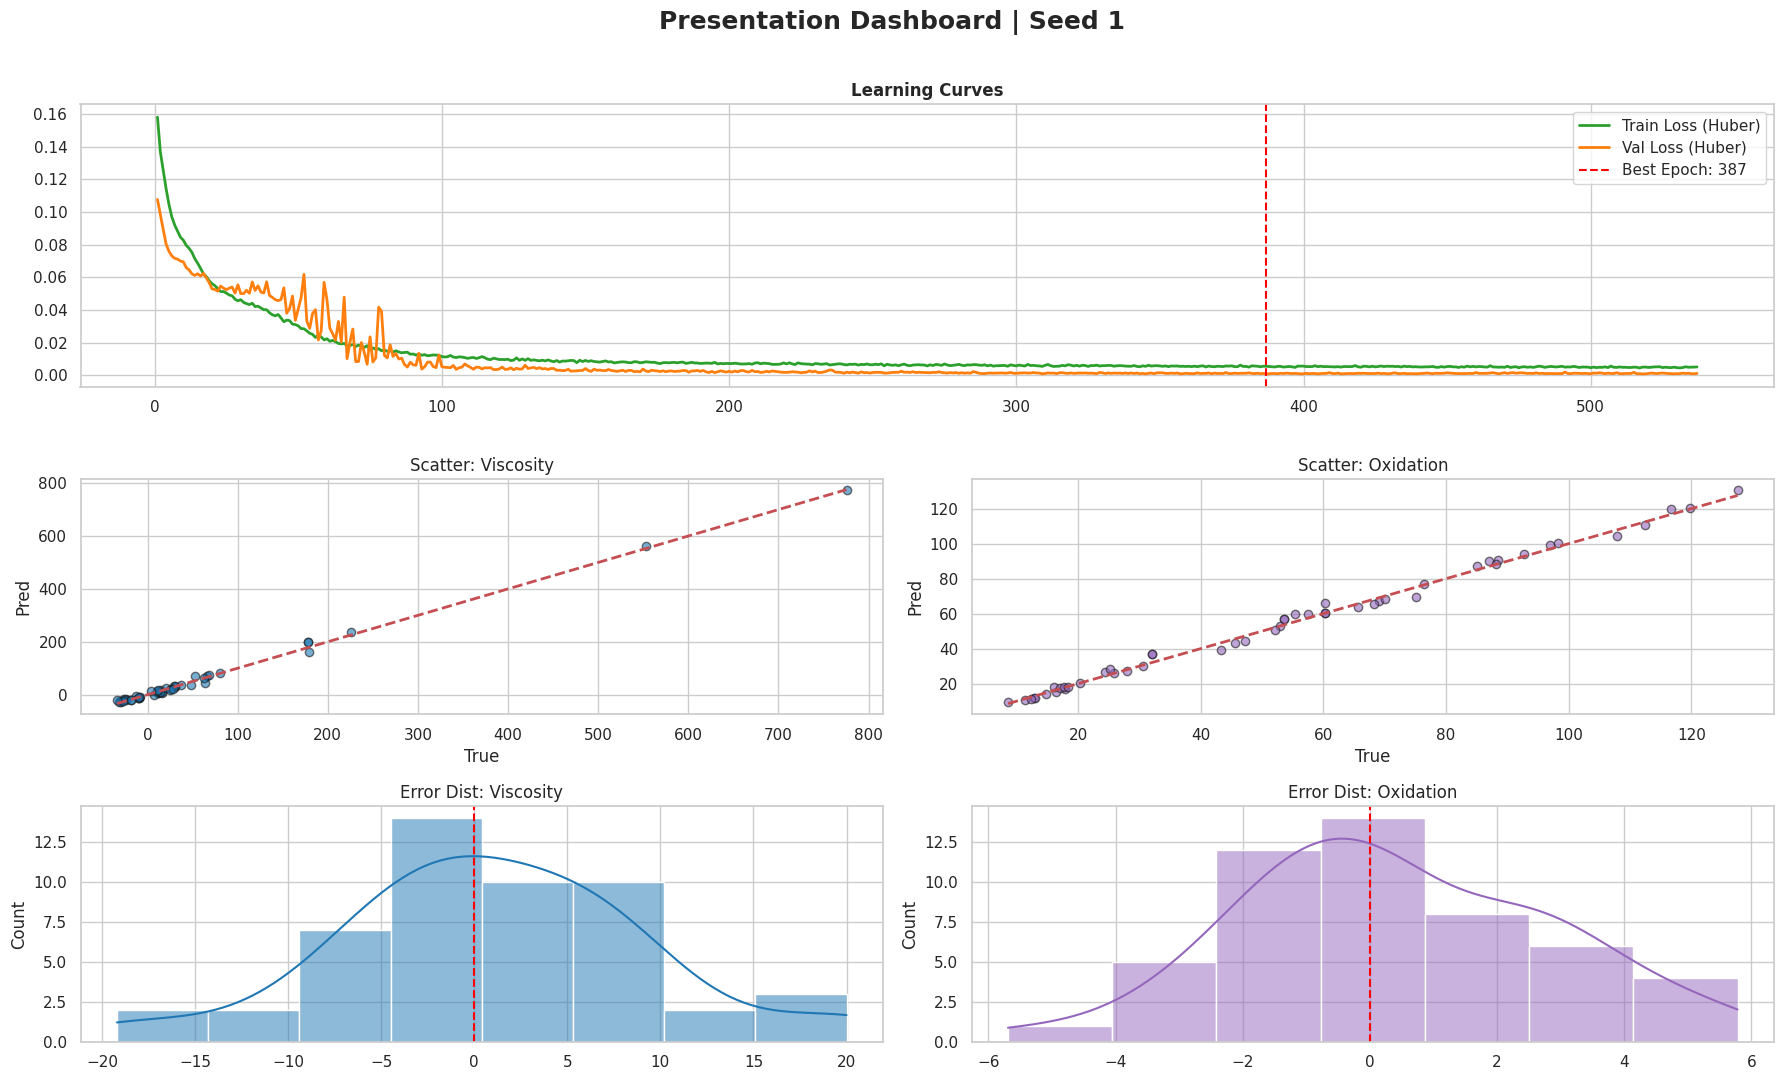

Готово! Сабмит 'predictions_t9.csv' успешно сформирован.


In [ ]:
# --- ОСНОВНОЙ ЦИКЛ ОБУЧЕНИЯ ---
train_aug_df = pd.read_csv(PATH_TRAIN_AUG).fillna(0)
val_clean_df = pd.read_csv(PATH_VAL_CLEAN).fillna(0)
test_df = pd.read_csv(PATH_TEST).fillna(0).rename(columns={'COMP_Ca_cnt': 'cnt_Ca', 'COMP_S_cnt': 'cnt_S', 'COMP_Zn_cnt': 'cnt_Zn', 'CHEM_logp': 'logp', 'CHEM_mol_wt': 'mol_wt', 'CHEM_rings': 'rings'})

feature_cols = get_feature_columns(train_aug_df)
comp_to_idx = build_component_vocab(train_aug_df, test_df)
train_scenarios = build_scenarios(train_aug_df, comp_to_idx, feature_cols, is_train=True)
val_scenarios = build_scenarios(val_clean_df, comp_to_idx, feature_cols, is_train=True)
test_scenarios = build_scenarios(test_df, comp_to_idx, feature_cols, is_train=False)

final_models, final_scalers = [], []

for seed_i in range(N_ENSEMBLE_SEEDS):
    s = SEED + seed_i * 137
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic, torch.backends.cudnn.benchmark = True, False

    train_ds = DOTDataset(train_scenarios, fit_scalers=True, augment=True)
    val_ds = DOTDataset(val_scenarios, train_ds.feat_scaler, train_ds.global_scaler, train_ds.target_scaler, augment=False)
    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    model = SetTransformerDOT(len(feature_cols)+1, len(comp_to_idx), D_MODEL, N_HEADS, N_LAYERS, D_FF, N_SEEDS, DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR, epochs=EPOCHS, steps_per_epoch=len(train_loader), pct_start=0.1)

    best_loss, best_state, patience_counter, best_epoch = float("inf"), None, 0, 0
    history = {'train': [], 'val': []}
    
    print(f"\n{'='*75}\nTRAINING SEED {seed_i+1} | PATIENCE: {PATIENCE}\n{'='*75}")
    print(f"{'Epoch':^8} | {'Train Loss':^12} | {'Val Loss':^12} | {'Best Loss':^12} | {'Patience'}")
    print("-" * 75)

    for epoch in range(1, EPOCHS + 1):
        model.train(); tr_loss = 0
        for b in train_loader:
            optimizer.zero_grad()
            p, _ = model(b[0].to(DEVICE), b[1].to(DEVICE), b[2].to(DEVICE), b[3].to(DEVICE))
            loss = custom_mae_loss(p, b[4].to(DEVICE)); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step(); scheduler.step()
            tr_loss += loss.item() * b[0].shape[0]
        
        tr_loss /= len(train_ds); val_loss = 0
        model.eval()
        with torch.no_grad():
            for b in val_loader:
                p, _ = model(b[0].to(DEVICE), b[1].to(DEVICE), b[2].to(DEVICE), b[3].to(DEVICE))
                val_loss += custom_mae_loss(p, b[4].to(DEVICE)).item() * b[0].shape[0]
        val_loss /= len(val_ds)
        
        history['train'].append(tr_loss); history['val'].append(val_loss)

        if val_loss < best_loss:
            best_loss, patience_counter, best_epoch = val_loss, 0, epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else: patience_counter += 1

        do_print = False
        if epoch <= 5: do_print = True
        elif epoch <= 25 and epoch % 5 == 0: do_print = True
        elif epoch > 25 and epoch % 25 == 0: do_print = True
        
        if do_print or patience_counter >= PATIENCE:
            print(f"{epoch:^8} | {tr_loss:^12.4f} | {val_loss:^12.4f} | {best_loss:^12.4f} | {patience_counter:^3}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print(f"\n[STP] Early stopping at epoch {epoch}. Best epoch: {best_epoch}"); break

    model.load_state_dict(best_state)
    final_models.append(model); final_scalers.append((train_ds.feat_scaler, train_ds.global_scaler, train_ds.target_scaler))
    plot_presentation_dashboard(history, best_epoch, model, val_loader, train_ds.target_scaler, DEVICE, seed_i+1)

# --- САБМИТ ---
all_preds = []
for model, (f_sc, g_sc, t_sc) in zip(final_models, final_scalers):
    test_ds = DOTDataset(test_scenarios, f_sc, g_sc, t_sc, augment=False)
    loader = DataLoader(test_ds, BATCH_SIZE, False, collate_fn=collate_fn)
    preds = []
    with torch.no_grad():
        for b in loader:
            p, _ = model(b[0].to(DEVICE), b[1].to(DEVICE), b[2].to(DEVICE), b[3].to(DEVICE))
            preds.append(t_sc.inverse_transform(p.cpu().numpy()))
    all_preds.append(np.concatenate(preds))

final_preds = np.maximum(np.mean(all_preds, axis=0), 0.0)
pd.DataFrame({"scenario_id": [s["scenario_id"] for s in test_scenarios], 
              TARGET_COLS_SUBMISSION[0]: final_preds[:, 0], 
              TARGET_COLS_SUBMISSION[1]: final_preds[:, 1]}).to_csv("predictions_t9.csv", index=False)
print("Готово! Сабмит 'predictions_t9.csv' успешно сформирован.")

In [3]:
print(torch.__version__)

2.8.0+cu128


In [ ]:
os.makedirs("weights", exist_ok=True)

print("Начинаем сохранение артефактов...")

config = {
    'len_feature_cols': len(feature_cols),
    'len_comp_to_idx': len(comp_to_idx)
}
joblib.dump(config, "weights/model_config.pkl")
print("✅ Конфигурация сохранена: weights/model_config.pkl")

for seed_i, (model, scalers) in enumerate(zip(final_models, final_scalers)):
    f_sc, g_sc, t_sc = scalers
    
    model_path = f"weights/model_seed_{seed_i}.pth"
    torch.save(model.state_dict(), model_path)
    
    f_sc_path = f"weights/feat_scaler_seed_{seed_i}.pkl"
    g_sc_path = f"weights/global_scaler_seed_{seed_i}.pkl"
    t_sc_path = f"weights/target_scaler_seed_{seed_i}.pkl"
    
    joblib.dump(f_sc, f_sc_path)
    joblib.dump(g_sc, g_sc_path)
    joblib.dump(t_sc, t_sc_path)
    
    print(f"✅ Seed {seed_i} сохранен: {model_path}, {f_sc_path}, {g_sc_path}, {t_sc_path}")

print("\n🎉 Все веса и скейлеры успешно сохранены в папку 'weights/'!")
print("Теперь вы можете перенести их в финальную структуру проекта и использовать в inference.ipynb.")

Начинаем сохранение артефактов...
✅ Конфигурация сохранена: weights/model_config.pkl
✅ Seed 0 сохранен: weights/model_seed_0.pth, weights/feat_scaler_seed_0.pkl, weights/global_scaler_seed_0.pkl, weights/target_scaler_seed_0.pkl

🎉 Все веса и скейлеры успешно сохранены в папку 'weights/'!
Теперь вы можете перенести их в финальную структуру проекта и использовать в inference.ipynb.


In [ ]:
import os
import joblib

os.makedirs("weights", exist_ok=True)
joblib.dump(comp_to_idx, "weights/comp_to_idx.pkl")

print("✅ Словарь компонентов успешно сохранен: weights/comp_to_idx.pkl")

✅ Словарь компонентов успешно сохранен: weights/comp_to_idx.pkl


In [ ]:
import os
import joblib
import torch

os.makedirs("weights2", exist_ok=True)

config = {
    'feature_cols': feature_cols,           # Сам список колонок
    'comp_to_idx': comp_to_idx,             # Сам словарь компонентов
    'len_feature_cols': len(feature_cols),  # Длина для нейросети
    'len_comp_to_idx': len(comp_to_idx)     # Длина для нейросети
}
joblib.dump(config, "weights2/model_config.pkl")

for seed_i, (model, scalers) in enumerate(zip(final_models, final_scalers)):
    f_sc, g_sc, t_sc = scalers
    
    torch.save(model.state_dict(), f"weights2/model_seed_{seed_i}.pth")
    joblib.dump(f_sc, f"weights2/feat_scaler_seed_{seed_i}.pkl")
    joblib.dump(g_sc, f"weights2/global_scaler_seed_{seed_i}.pkl")
    joblib.dump(t_sc, f"weights2/target_scaler_seed_{seed_i}.pkl")

print("✅ Конфиг, веса и скейлеры успешно сохранены!")

✅ Конфиг, веса и скейлеры успешно сохранены!
